In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import subprocess
import os
import folium
import folium.plugins
import datetime
alt.data_transformers.disable_max_rows()
import warnings
warnings.filterwarnings("ignore")



os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


from r5py.util.config import Config
import r5py

Number of intersections:  166596
Number of road segments: 509190


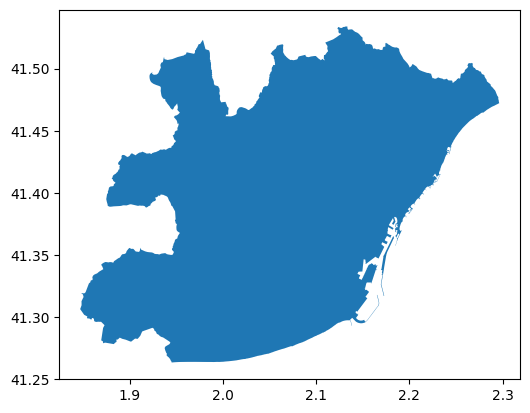

In [2]:
# Importing osmnx

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Àrea Metropolitana de Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [3]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [4]:
bus_sol = pd.read_csv('Nodes/Bus-Sol.csv')
bus = pd.read_csv('Nodes/Bus.csv')
fgc_sol = pd.read_csv('Nodes/FGC-Sol.csv')
fgc = pd.read_csv('Nodes/FGC.csv')
metro_sol = pd.read_csv('Nodes/Metro-Sol.csv')
metro = pd.read_csv('Nodes/Metro.csv')
tram_sol = pd.read_csv('Nodes/Tram-Sol.csv')
tram = pd.read_csv('Nodes/Tram.csv')
destinations = pd.read_csv('Nodes/Destinations.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


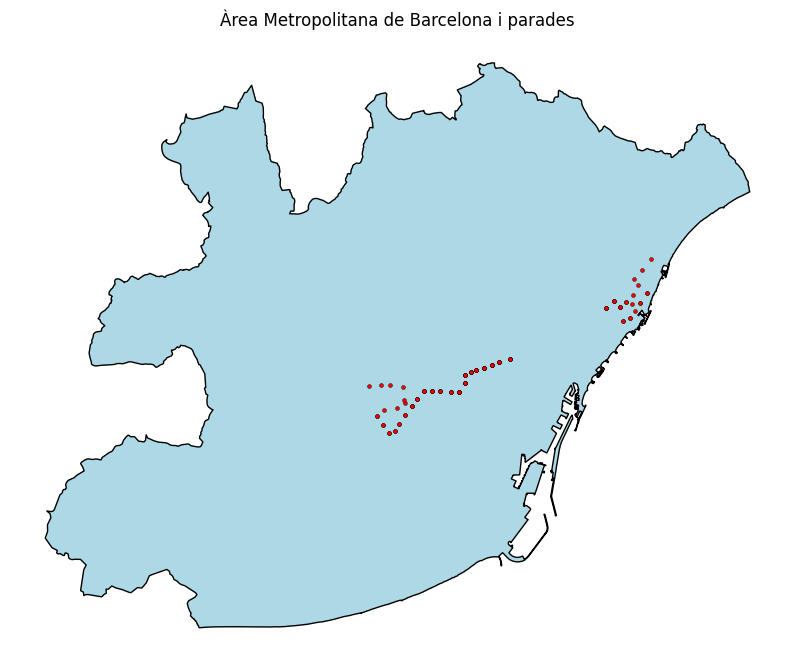

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

admin_district.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=1
)

all_stops[all_stops['stop_type'] == 'Tram'].plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Àrea Metropolitana de Barcelona i parades")
ax.axis("off")
plt.show()

In [9]:
walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed


isochrone_time = 5
isochrone_polys = []

process = 1
for stop in all_stops['stop_id'].unique():
    print(f"Processing stop {stop} ({process}/{len(all_stops['stop_id'].unique())})")
    process += 1
    p = all_stops[all_stops['stop_id'] == stop].iloc[0]
    center_node = ox.distance.nearest_nodes(G, X=p['geometry'].x, Y=p["geometry"].y)

    subgraph = nx.ego_graph(
            G,
            center_node,
            radius= isochrone_time * 60,
            distance="travel_time"
        )

    node_points = [
        Point((data["x"], data["y"]))
        for node, data in subgraph.nodes(data=True)
    ]

    center_point = Point(G.nodes[center_node]["x"], G.nodes[center_node]["y"])

    polygon = gpd.GeoSeries(node_points).union_all().convex_hull
    isochrone_polys.append(
            gpd.GeoDataFrame(
                {"stop_id": [p["stop_id"]], "geometry": [polygon]},
                crs="EPSG:4326"
            )
        )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

Processing stop 2 (1/3342)
Processing stop 3 (2/3342)
Processing stop 7 (3/3342)
Processing stop 8 (4/3342)
Processing stop 13 (5/3342)
Processing stop 20 (6/3342)
Processing stop 21 (7/3342)
Processing stop 22 (8/3342)
Processing stop 24 (9/3342)
Processing stop 25 (10/3342)
Processing stop 31 (11/3342)
Processing stop 32 (12/3342)
Processing stop 34 (13/3342)
Processing stop 38 (14/3342)
Processing stop 39 (15/3342)
Processing stop 41 (16/3342)
Processing stop 42 (17/3342)
Processing stop 43 (18/3342)
Processing stop 44 (19/3342)
Processing stop 48 (20/3342)
Processing stop 51 (21/3342)
Processing stop 55 (22/3342)
Processing stop 58 (23/3342)
Processing stop 60 (24/3342)
Processing stop 63 (25/3342)
Processing stop 65 (26/3342)
Processing stop 69 (27/3342)
Processing stop 82 (28/3342)
Processing stop 94 (29/3342)
Processing stop 95 (30/3342)
Processing stop 98 (31/3342)
Processing stop 103 (32/3342)
Processing stop 105 (33/3342)
Processing stop 106 (34/3342)
Processing stop 108 (35/

In [10]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isochrone_polys['stop_id'].unique())].merge(isochrone_polys, on='stop_id', how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
3,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."
4,SB-13,13,Sas - Claramunt,IU Stop,Bus,"POLYGON ((2.20584 41.4342, 2.20432 41.43434, 2..."
...,...,...,...,...,...,...
7026,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22446 41.42451, 2.22411 41.42458, ..."
7027,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21987 41.42728, 2.21921 41.42804, ..."
7028,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22644 41.43243, 2.22467 41.43269, ..."
7029,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.23004 41.43745, 2.22926 41.43984, ..."


In [11]:
test = all_stops.copy()
isocores_df_all_merge = isocores_df_all.copy()
test.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.to_crs('EPSG:25831', inplace=True)
test.rename(columns={'id': 'destination_id','stop_id':'destination_stop_id','name':'destination_stop_name','linia':'destination_linia','stop_type':'destination_stop_type'}, inplace=True)
isocores_df_all_merge.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'origin_linia','stop_type':'origin_stop_type'}, inplace=True)
close_stops = gpd.sjoin(test[test['destination_id'].isin(isocores_df_all_merge['origin_id'])], isocores_df_all_merge, how='inner', predicate='within')
close_stops = close_stops[close_stops['origin_id'] != close_stops['destination_id']]
close_stops = close_stops[~close_stops['destination_id'].str.startswith('S')]
close_stops = close_stops[['origin_id', 'origin_stop_id', 'origin_stop_type', 'origin_stop_name', 'origin_linia', 'destination_id', 'destination_stop_id', 'destination_stop_type', 'destination_stop_name', 'destination_linia']]
close_stops['tram'] = close_stops['origin_stop_name'] + ' - ' + close_stops['destination_stop_name']
close_stops['mode'] = close_stops['origin_stop_type'] + ' - ' + close_stops['destination_stop_type']
close_stops['lines'] = close_stops['origin_linia'] + ' - ' + close_stops['destination_linia']
close_stops.drop(columns=['origin_stop_name', 'destination_stop_name','origin_linia','destination_linia'], inplace=True)
close_stops

,origin_id,origin_stop_id,origin_stop_type,destination_id,destination_stop_id,destination_stop_type,tram,mode,lines
812,SB-2,2,Bus,B-59-2,2,Bus,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,SB-34,34,Bus,B-59-2,2,Bus,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,SB-342,342,Bus,B-59-2,2,Bus,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,SB-698,698,Bus,B-59-2,2,Bus,Av Icària - Joan Miró - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,B-H16-2,2,Bus,B-59-2,2,Bus,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,H16 - 59
...,...,...,...,...,...,...,...,...,...
7030,B-V33-3596,3596,Bus,T-T6-MINA,MINA,Tram,La Mina - Ponent - La Mina,Bus - Tram,V33 - T6
7030,B-B23-105999,105999,Bus,T-T6-MINA,MINA,Tram,Rambla de la Mina - La Mina,Bus - Tram,B23 - T6
7030,B-B23-106000,106000,Bus,T-T6-MINA,MINA,Tram,CAP La Mina - La Mina,Bus - Tram,B23 - T6
7030,T-T5-PARC,PARC,Tram,T-T6-MINA,MINA,Tram,Parc del Besòs - La Mina,Tram - Tram,T5 - T6


In [12]:
same_stops = close_stops[
    (close_stops['origin_stop_id'] == close_stops['destination_stop_id']) & (close_stops['origin_stop_type'] == close_stops['destination_stop_type'])
].copy()
same_stops = same_stops.drop(columns=['origin_stop_id', 'destination_stop_id'])

conditions = [
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
    same_stops['origin_id'].str.startswith('B', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith(('M', 'F'), na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('T', na=False) & same_stops['destination_id'].str.startswith('T', na=False),

]
choices = [3, 1, 2, 1, 2, 1]
same_stops['type'] = 'Exchange - Self'
same_stops['time'] = pd.to_timedelta(
    np.select(conditions, choices, default=0),
    unit='m'
)

same_stops['time'] = same_stops['time'].apply(
    lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
)
same_stops['geometry'] = same_stops.apply(lambda row: all_stops.loc[all_stops['id'] == row['origin_id'], 'geometry'].values[0], axis=1)
same_stops.drop(columns=['origin_stop_type', 'destination_stop_type'], inplace=True)


In [ ]:
# cache_dir = Config().CACHE_DIR
# for f in cache_dir.glob("*.mapdb*"):
#     f.unlink()

In [14]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [15]:
itineraries = pd.DataFrame()
process = 0
failed_iteraries = []
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]


for stop in different_stops['origin_stop_id'].unique():
    process += 1
    print(f"Processing {process}/{different_stops['origin_stop_id'].nunique()}")
    stops = different_stops[different_stops['origin_stop_id'] == stop]
    stops.drop_duplicates(subset=['origin_stop_id', 'destination_stop_id'], inplace=True)

    for _, row in stops.iterrows():
        origin_id = row['origin_stop_id']
        destination_id = row['destination_stop_id']

        # if origin_id  != 342:
        #     continue
        # if destination_id != 2:
        #     continue

        # if process != 2374:
        #     continue

        origins = all_stops[all_stops['stop_id'] == origin_id].copy()
        origins.drop_duplicates(subset=['stop_id'], inplace=True)
        destinations = all_stops[all_stops['stop_id'] == destination_id].copy()
        destinations.drop_duplicates(subset=['stop_id'], inplace=True)
        origins.rename(columns={'origin_id': 'id'}, inplace=True)
        destinations.rename(columns={'destination_id': 'id'}, inplace=True)
        origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
        destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
        detailed_itineraries = r5py.DetailedItineraries(
            transport_network,
            origins=origins,
            destinations=destinations,
            transport_modes=[r5py.TransportMode.WALK],
            snap_to_network=True,
            speed_walking = 5,
            departure=datetime.datetime(2026, 5, 13, 9, 30),

        )

        if len(detailed_itineraries) == 0:
            failed_iteraries.append((origin_id, destination_id))
            continue
        exchange_time = detailed_itineraries['travel_time'].sum()
        itineraries_row = pd.DataFrame({
            'origin_stop_id': [origin_id],
            'destination_stop_id': [destination_id],
            'time': [exchange_time],
            'geometry': [detailed_itineraries['geometry'].iloc[0]],
        })

        itineraries_row = gpd.GeoDataFrame(itineraries_row, geometry='geometry', crs="EPSG:4326")
        itineraries = pd.concat([itineraries, itineraries_row], ignore_index=True)


itineraries["time"] = itineraries["time"].apply(
    lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
)


Processing 1/3284
Processing 2/3284
Processing 3/3284
Processing 4/3284
Processing 5/3284
Processing 6/3284
Processing 7/3284
Processing 8/3284
Processing 9/3284
Processing 10/3284
Processing 11/3284
Processing 12/3284
Processing 13/3284
Processing 14/3284
Processing 15/3284
Processing 16/3284
Processing 17/3284
Processing 18/3284
Processing 19/3284
Processing 20/3284
Processing 21/3284
Processing 22/3284
Processing 23/3284
Processing 24/3284
Processing 25/3284
Processing 26/3284
Processing 27/3284
Processing 28/3284
Processing 29/3284
Processing 30/3284
Processing 31/3284
Processing 32/3284
Processing 33/3284
Processing 34/3284
Processing 35/3284
Processing 36/3284
Processing 37/3284
Processing 38/3284
Processing 39/3284
Processing 40/3284
Processing 41/3284
Processing 42/3284
Processing 43/3284
Processing 44/3284
Processing 45/3284
Processing 46/3284
Processing 47/3284
Processing 48/3284
Processing 49/3284
Processing 50/3284
Processing 51/3284
Processing 52/3284
Processing 53/3284
Pr

In [17]:
different_stops_final

,origin_id,destination_id,tram,mode,lines,type,time,geometry
0,SB-34,B-59-2,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange,00:49,"LINESTRING (2.19972 41.39341, 2.1997 41.39339,..."
1,SB-342,B-59-2,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange,05:00,"LINESTRING (2.20291 41.3947, 2.20226 41.39416,..."
2,SB-698,B-59-2,Av Icària - Joan Miró - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange,04:50,"LINESTRING (2.19587 41.39, 2.19608 41.3902, 2...."
3,B-H16-34,B-59-2,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,H16 - 59,Exchange,00:49,"LINESTRING (2.19972 41.39341, 2.1997 41.39339,..."
4,B-V27-34,B-59-2,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,V27 - 59,Exchange,00:49,"LINESTRING (2.19972 41.39341, 2.1997 41.39339,..."
...,...,...,...,...,...,...,...,...
149316,B-V33-3596,T-T6-MINA,La Mina - Ponent - La Mina,Bus - Tram,V33 - T6,Exchange,04:34,"LINESTRING (2.21728 41.41881, 2.2174 41.41866,..."
149317,B-B23-105999,T-T6-MINA,Rambla de la Mina - La Mina,Bus - Tram,B23 - T6,Exchange,01:48,"LINESTRING (2.22243 41.41822, 2.22234 41.41811..."
149318,B-B23-106000,T-T6-MINA,CAP La Mina - La Mina,Bus - Tram,B23 - T6,Exchange,04:10,"LINESTRING (2.22018 41.41563, 2.22041 41.41589..."
149319,T-T5-PARC,T-T6-MINA,Parc del Besòs - La Mina,Tram - Tram,T5 - T6,Exchange,04:51,"LINESTRING (2.21713 41.41916, 2.21717 41.41919..."


In [18]:
different_stops_final = different_stops.merge(itineraries, on=['origin_stop_id', 'destination_stop_id'], how='left')
different_stops_final.drop(columns=['origin_stop_id', 'destination_stop_id','destination_stop_type','origin_stop_type'], inplace=True)
different_stops_final.insert(5, 'type', 'Exchange')
different_stops_final = different_stops_final[different_stops_final['geometry'].notnull()]

In [19]:
all_exchanges = pd.concat([same_stops, different_stops], ignore_index=True)
all_exchanges.rename(columns={'origin_id': 'origen', 'destination_id': 'dest','exchange_time':'time'}, inplace=True)
all_exchanges = gpd.GeoDataFrame(all_exchanges, geometry='geometry', crs="EPSG:4326")
all_exchanges = all_exchanges[all_exchanges['time'] <= '05:00']
all_exchanges.insert(7, 'directed', True)

In [25]:
all_exchanges

,origen,dest,tram,mode,lines,type,time,directed,geometry,origin_stop_id,origin_stop_type,destination_stop_id,destination_stop_type
0,SB-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange - Self,01:00,True,POINT (2.19898 41.3931),NaN,NaN,NaN,NaN
1,B-H16-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,H16 - 59,Exchange - Self,01:00,True,POINT (2.19898 41.3931),NaN,NaN,NaN,NaN
2,B-V27-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,V27 - 59,Exchange - Self,01:00,True,POINT (2.19898 41.3931),NaN,NaN,NaN,NaN
3,SB-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - H16,Exchange - Self,01:00,True,POINT (2.19898 41.3931),NaN,NaN,NaN,NaN
4,B-59-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,59 - H16,Exchange - Self,01:00,True,POINT (2.19898 41.3931),NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11976,T-T6-ALFS,T-T5-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,T6 - T5,Exchange - Self,01:00,True,POINT (2.21357 41.41719),NaN,NaN,NaN,NaN
11977,ST-ALFS,T-T6-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,IU Stop - T6,Exchange - Self,02:00,True,POINT (2.21357 41.41719),NaN,NaN,NaN,NaN
11978,T-T5-ALFS,T-T6-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,T5 - T6,Exchange - Self,01:00,True,POINT (2.21357 41.41719),NaN,NaN,NaN,NaN
11979,T-T6-PARC,T-T5-PARC,Parc del Besòs - Parc del Besòs,Tram - Tram,T6 - T5,Exchange - Self,01:00,True,POINT (2.21763 41.41943),NaN,NaN,NaN,NaN


In [24]:
all_exchanges.to_csv('Edges/Exchanges.csv', index=False)

In [18]:
# Frame 1: polygons only
isochrone_chart = alt.Chart(isocores_df_all[isocores_df_all['stop_id'].isin([2575])]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['stop_id'].isin([2575,84])]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(all_exchanges[all_exchanges['origen'].isin(['B-B80-2575']) & (all_exchanges['dest'].isin(['B-B18-84']))]).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
isochrone_chart + points + itineraries_chart  ).properties(
    width=900,
    height=900
)

alt.LayerChart(...)

In [ ]:
# Frame 1: polygons only
polys_df = isocores_df_all[['id', 'geometry']].copy()
polys_df = gpd.GeoDataFrame(polys_df, geometry='geometry', crs="EPSG:4326")


not_self_exchanges = all_exchanges[all_exchanges['type'] == 'Exchange'].copy()
#not_self_exchanges = not_self_exchanges[not_self_exchanges['mode'] == 'Bus - Tram']
origens = not_self_exchanges['origen'].unique().tolist()
destinations = not_self_exchanges['dest'].unique().tolist()
stops =  origens + destinations

isochrone_chart = alt.Chart(polys_df[polys_df['id'].isin(origens)]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['id'].isin(stops)]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(not_self_exchanges).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
neigh_layer + isochrone_chart).properties(
    width=900,
    height=900
)

MaxRowsError: The number of rows in your dataset (8390) is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.LayerChart(...)

In [ ]:



# ---------------------------------------------------------
# Load neighbourhoods
# ---------------------------------------------------------

neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)

neigh = neigh[["name", "geometry"]]

neigh["geometry"] = neigh.geometry.buffer(0)


# ---------------------------------------------------------
# Prepare itinerary data
# ---------------------------------------------------------

itineraries["mode"] = itineraries["transport_mode"].astype(str)

itineraries["travel time (min)"] = itineraries["travel_time"].apply(
    lambda t: round(t.total_seconds() / 60.0, 2)
)

itineraries["trip"] = itineraries.apply(
    lambda row: f"{row['from_id']} → {row['to_id']}",
    axis=1
)


# ---------------------------------------------------------
# Create map
# ---------------------------------------------------------



detailed_routes_map = (
    itineraries[
        [
            "geometry",
            "distance",
            "mode",
            "travel time (min)",
            "from_id",
            "to_id",
            "trip",
            "option",
            "segment",
        ]
    ]
    .explore(
        tooltip=[
            "trip",
            "option",
            "segment",
            "mode",
            "travel time (min)",
            "distance",
        ],
        column="mode",
        tiles="CartoDB.Positron",
        style_kwds={
            "weight": 3,
            "opacity": 0.8,
        },
        highlight_kwds={
            "weight": 6,
            "opacity": 1,
        },
    )
)


isochrone_polys.explore(
    m=detailed_routes_map,
    tooltip=["stop_id"],
    style_kwds={
        "fillOpacity": 0.15,
        "weight": 1,
    },
)

# ---------------------------------------------------------
# Get stops involved in the itineraries
# ---------------------------------------------------------

stop_ids = pd.unique(
    pd.concat([
        itineraries["from_id"],
        itineraries["to_id"]
    ])
)

stops_map = all_stops[
    all_stops["id"].isin(stop_ids)
].copy()

stops_map = gpd.GeoDataFrame(
    stops_map,
    geometry="geometry",
    crs="EPSG:4326"
)


# ---------------------------------------------------------
# Assign neighbourhood to each stop
# ---------------------------------------------------------

# Project both layers for the spatial join
stops_projected = stops_map.to_crs("EPSG:25831")
neigh_projected = neigh.to_crs("EPSG:25831")

stops_map = gpd.sjoin(
    stops_projected,
    neigh_projected[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Return to WGS84 for Folium
stops_map = stops_map.to_crs("EPSG:4326")


# ---------------------------------------------------------
# Add stop markers
# ---------------------------------------------------------

stops_map.apply(
    lambda row: folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        tooltip=(
            f"Stop: {row['id']}<br>"
        ),
        icon=folium.plugins.BeautifyIcon(
            icon_shape="marker",
            number=str(row["id"]),
            border_color="#728224",
            text_color="#728224",
        ),
    ).add_to(detailed_routes_map),
    axis=1,
)


detailed_routes_map